# Урок 15.12. Линейная алгебра: векторы, матрицы, проекции

**Интерактивная версия:** `lessons/lesson_15_12/web/index.html`

После урока вы сможете:

- складывать векторы, строить линейные комбинации, проверять независимость и находить координаты в базисе;
- считать скалярное произведение, длины, углы, расстояния и проекции; объяснять, почему лучшая константа — среднее;
- выражать потери и регуляризацию через нормы $L_1$, $L_2$, $L_\infty$;
- умножать матрицы, вычислять определитель и обратную матрицу, решать системы методом Гаусса;
- распознавать вырожденность, мультиколлинеарность и плохую обусловленность;
- выводить и решать нормальные уравнения МНК и гребневой регрессии;
- находить собственные числа и векторы, классифицировать квадратичные формы и связывать обусловленность со скоростью спуска;
- объяснять SVD, малоранговое приближение и PCA;
- описывать бустинг как цепочку проекций антиградиента на ступеньки деревьев.

Разделы ноутбука идут в том же порядке, что и 33 шага урока (шесть блоков). Каждое числовое утверждение урока
проверяется здесь расчётом, ключевые — сверкой с `numpy.linalg`, scikit-learn, XGBoost и учебной библиотекой `gbcourse`.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import datasets
from gbcourse.boosting import GBRegressor
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, INK, MUTED, ORANGE, VIOLET

use_course_style()
np.set_printoptions(precision=4, suppress=True)

X1, y = datasets.toy_regression()        # шесть квартир: площадь (десятки м²) и цена (млн)
x = X1[:, 0]
X = np.c_[np.ones(6), x]                 # матрица признаков со столбцом единиц
print("x =", x, "\ny =", y)

x = [1. 2. 3. 4. 5. 6.] 
y = [ 2.  4.  3.  7.  9. 11.]


## Интуиция: три квартиры — одна точка в пространстве

Цены трёх квартир — точка $y = (2, 4, 3) \in \mathbb R^3$. Константные прогнозы лежат на прямой $c\cdot\mathbf 1$,
прогнозы прямых $b + kx$ — на плоскости, натянутой на $\mathbf 1$ и $x = (1, 2, 3)$. Лучшие прогнозы — ортогональные проекции.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


лучшая константа: 3.0  ‖y − c·1‖² = 2.0  (y − c·1)·1 = 0.0
лучшая прямая: b, k = [2.  0.5]  ŷ = [2.5 3.  3.5]  r = [-0.5  1.  -0.5]  ‖r‖² = 1.5


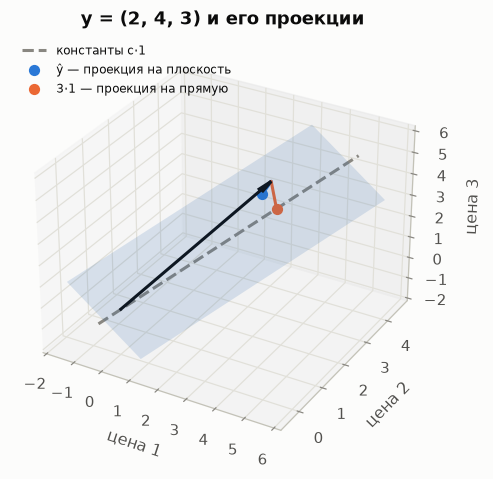

In [2]:
y3, x3, one3 = y[:3], x[:3], np.ones(3)
c = (one3 @ y3) / (one3 @ one3)
print("лучшая константа:", c, " ‖y − c·1‖² =", (y3 - c) @ (y3 - c), " (y − c·1)·1 =", (y3 - c).sum())
X3 = np.c_[one3, x3]
w3 = np.linalg.solve(X3.T @ X3, X3.T @ y3)
r3 = y3 - X3 @ w3
print("лучшая прямая: b, k =", w3, " ŷ =", X3 @ w3, " r =", r3, " ‖r‖² =", r3 @ r3)
assert np.isclose(c, 3) and np.allclose(X3 @ w3, [2.5, 3, 3.5]) and np.isclose(r3 @ r3, 1.5)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection="3d")
ax.quiver(0, 0, 0, *y3, color=INK, lw=2, arrow_length_ratio=0.08)
ax.plot([-0.4, 4.6], [-0.4, 4.6], [-0.4, 4.6], "--", color=MUTED, label="константы c·1")
s_, t_ = np.meshgrid(np.linspace(-0.3, 4.4, 2), np.linspace(-1.3, 1.3, 2))
ax.plot_surface(s_ - t_, s_, s_ + t_, color=BLUE, alpha=0.15)
ax.scatter(*X3 @ w3, color=BLUE, s=40, label="ŷ — проекция на плоскость")
ax.scatter(3, 3, 3, color=ORANGE, s=40, label="3·1 — проекция на прямую")
ax.plot(*np.c_[X3 @ w3, y3], color=BLUE)
ax.plot(*np.c_[[3, 3, 3], y3], color=ORANGE)
ax.set(xlabel="цена 1", ylabel="цена 2", zlabel="цена 3", title="y = (2, 4, 3) и его проекции")
ax.legend(fontsize=8, loc="upper left")
plt.show()

## Блок 1. Векторы

### Шаги 1–3. Действия, линейные комбинации, базис

In [3]:
a, b = np.array([3.0, 1.0]), np.array([1.0, 2.0])
print("a + b =", a + b, " a − b =", a - b, " 2a − b =", 2 * a - b)
r = y - 6
print("остатки r = y − 6 =", r)
print("шаг бустинга F₁ = F₀ + 0.5·h₁:", 6 + 0.5 * np.array([-3, -3, -3, 3, 3, 3]))

u, v = np.array([1.0, 1.0]), np.array([1.0, -1.0])
print("α, β для цели (3, 1):", np.linalg.solve(np.c_[u, v], [3, 1.0]))
print("координаты (1, 2) в базисе (2, 1), (−1, 1):", np.linalg.solve(np.c_[[2, 1.0], [-1, 1.0]], [1, 2.0]))
B3 = np.array([[1, 0, 1], [0, 1, 1], [1, 1, 0.0]])
print("det [(1,0,1), (0,1,1), (1,1,0)] =", round(np.linalg.det(B3), 10), "— базис ℝ³")

district = np.array([0, 0, 1, 1, 2, 2])
D = np.c_[np.ones(6), np.eye(3)[district]]
print("сдвиг + 3 индикатора района: ранг", np.linalg.matrix_rank(D), "из", D.shape[1], "— ловушка фиктивных переменных")

a + b = [4. 3.]  a − b = [ 2. -1.]  2a − b = [5. 0.]
остатки r = y − 6 = [-4. -2. -3.  1.  3.  5.]
шаг бустинга F₁ = F₀ + 0.5·h₁: [4.5 4.5 4.5 7.5 7.5 7.5]
α, β для цели (3, 1): [2. 1.]
координаты (1, 2) в базисе (2, 1), (−1, 1): [1. 1.]
det [(1,0,1), (0,1,1), (1,1,0)] = -2.0 — базис ℝ³
сдвиг + 3 индикатора района: ранг 3 из 4 — ловушка фиктивных переменных


### Шаги 4–5. Скалярное произведение, углы, расстояния и масштаб признаков

In [4]:
a, b = np.array([3.0, 4.0]), np.array([4.0, -1.0])
cos = a @ b / (np.linalg.norm(a) * np.linalg.norm(b))
print(f"(3, 4)·(4, −1) = {a @ b}, ‖b‖ = {np.linalg.norm(b):.3f}, угол {np.degrees(np.arccos(cos)):.1f}°")
print("(1, 1, 0)·(0, 1, 1): угол", np.degrees(np.arccos(1 / 2)), "°")
print("прогноз w·x:", np.array([0.5, 1.8, 0.1]) @ np.array([1, 5, 3.0]))
t1, t2, t3 = np.array([2, 1, 0.0]), np.array([4, 2, 0.0]), np.array([0, 1, 3.0])
cs = lambda p, q: p @ q / np.linalg.norm(p) / np.linalg.norm(q)
print(f"косинус текстов: {cs(t1, t2):.3f} и {cs(t1, t3):.3f}")

area = np.array([30, 35, 42, 50, 62, 70, 78, 90.0])
dist = np.array([12, 3, 9, 4, 10, 2, 8, 3.0])
price = np.array([3.0, 5.0, 3.6, 5.8, 7.0, 9.6, 7.8, 10.6])
q = np.array([58.0, 4.0])
for name, sx, sy in (("м², км", 1, 1), ("м², метры", 1, 1000), ("стандартизованные", 1 / area.std(), 1 / dist.std())):
    d = np.hypot((area - q[0]) * sx, (dist - q[1]) * sy)
    o = np.argsort(d)
    print(f"{name:18}: ближайшие №{o[0] + 1} ({d[o[0]]:.2f}), №{o[1] + 1} ({d[o[1]]:.2f}); цена соседа {price[o[0]]}")
print(f"стандартные отклонения: {area.std():.1f} м², {dist.std():.2f} км")

(3, 4)·(4, −1) = 8.0, ‖b‖ = 4.123, угол 67.2°
(1, 1, 0)·(0, 1, 1): угол 60.00000000000001 °
прогноз w·x: 9.8
косинус текстов: 1.000 и 0.141
м², км            : ближайшие №5 (7.21), №4 (8.00); цена соседа 7.0
м², метры         : ближайшие №4 (8.00), №2 (1000.26); цена соседа 5.8
стандартизованные : ближайшие №4 (0.40), №6 (0.82); цена соседа 5.8
стандартные отклонения: 20.0 м², 3.57 км


### Шаг 6. Проекция на вектор и лучшая константа

проекция (2, 3) на (1, 0): [2. 0.]  на (1, 1): [2.5 2.5]
проекция y на 1: [6. 6. 6. 6. 6. 6.]  — среднее 6.0
Пифагор: 280.0 = 216.0 + 64.0
взвешенная проекция на 1 = взвешенное среднее: 6.444444444444445 = 6.444444444444445


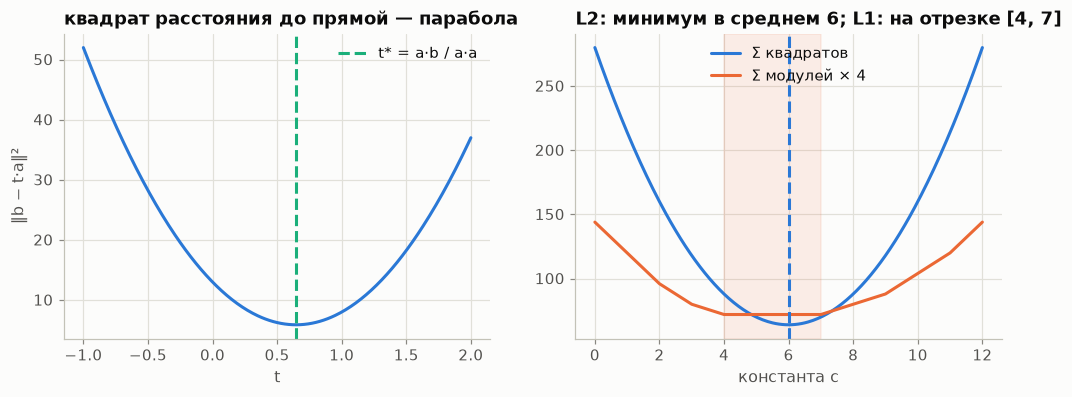

In [5]:
proj = lambda a, b: (a @ b) / (a @ a) * a
print("проекция (2, 3) на (1, 0):", proj(np.array([1.0, 0]), np.array([2.0, 3])), " на (1, 1):", proj(np.array([1.0, 1]), np.array([2.0, 3])))
one = np.ones(6)
p = proj(one, y)
print("проекция y на 1:", p, " — среднее", y.mean())
print("Пифагор:", y @ y, "=", p @ p, "+", (y - p) @ (y - p))
h = np.array([1, 2, 1, 1, 3, 1.0])                  # веса объектов
print("взвешенная проекция на 1 = взвешенное среднее:", (h * y).sum() / h.sum(), "=", np.average(y, weights=h))

ts = np.linspace(-1, 2, 301)
a, b = np.array([4.0, 1.0]), np.array([2.0, 3.0])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(ts, [(b - t * a) @ (b - t * a) for t in ts], color=BLUE)
ax[0].axvline((a @ b) / (a @ a), color=AQUA, ls="--", label="t* = a·b / a·a")
ax[0].set(xlabel="t", ylabel="‖b − t·a‖²", title="квадрат расстояния до прямой — парабола")
ax[0].legend()
cc = np.linspace(0, 12, 241)
ax[1].plot(cc, [((y - c) ** 2).sum() for c in cc], color=BLUE, label="Σ квадратов")
ax[1].plot(cc, [np.abs(y - c).sum() * 4 for c in cc], color=ORANGE, label="Σ модулей × 4")
ax[1].axvline(6, color=BLUE, ls="--")
ax[1].axvspan(4, 7, color=ORANGE, alpha=0.1)
ax[1].set(xlabel="константа c", title="L2: минимум в среднем 6; L1: на отрезке [4, 7]")
ax[1].legend()
plt.show()

### Шаг 7. Нормы, потери и регуляризация

‖r‖₂ = 8.0, ‖r‖₁ = 18.0, ‖r‖∞ = 5.0
MSE = 10.6667, RMSE = 3.2660, MAE = 3.0
с выбросом: среднее 7.67 (было 6), медиана 5.5 (было 5.5)
a = 0.5, λ = 0.5: L2 → 0.333, L1 (мягкий порог) → 0.000
a = 0.5, λ = 1.0: L2 → 0.250, L1 (мягкий порог) → 0.000
a = 2.0, λ = 0.5: L2 → 1.333, L1 (мягкий порог) → 1.500
a = 2.0, λ = 1.0: L2 → 1.000, L1 (мягкий порог) → 1.000


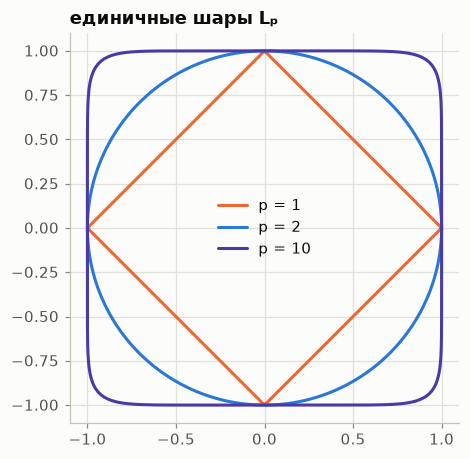

In [6]:
r = y - 6
print(f"‖r‖₂ = {np.linalg.norm(r)}, ‖r‖₁ = {np.linalg.norm(r, 1)}, ‖r‖∞ = {np.linalg.norm(r, np.inf)}")
print(f"MSE = {r @ r / 6:.4f}, RMSE = {np.sqrt(r @ r / 6):.4f}, MAE = {np.abs(r).mean()}")
y_out = y.copy()
y_out[-1] = 21
print(f"с выбросом: среднее {y_out.mean():.2f} (было 6), медиана {np.median(y_out)} (было {np.median(y)})")
for a_ in (0.5, 2.0):
    for lam in (0.5, 1.0):
        print(f"a = {a_}, λ = {lam}: L2 → {a_ / (1 + lam):.3f}, L1 (мягкий порог) → {np.sign(a_) * max(abs(a_) - lam, 0):.3f}")

fig, ax = plt.subplots(figsize=(4.6, 4.6))
t = np.linspace(0, 2 * np.pi, 400)
for pp, col in ((1, ORANGE), (2, BLUE), (10, VIOLET)):
    n = (np.abs(np.cos(t)) ** pp + np.abs(np.sin(t)) ** pp) ** (1 / pp)
    ax.plot(np.cos(t) / n, np.sin(t) / n, color=col, lw=2, label=f"p = {pp}")
ax.set(aspect="equal", title="единичные шары Lₚ")
ax.legend()
plt.show()

### Шаг 8. Гиперплоскости и разбиения деревьев

In [7]:
w_, b_ = np.array([2.0, 1.0]), 4.0
print("расстояние от (3, 3) до прямой 2x₁ + x₂ = 4:", (w_ @ [3, 3] - b_) / np.linalg.norm(w_))
from sklearn.tree import DecisionTreeClassifier

rng = Mulberry32(7)
P = np.array([[rng.uniform(-3, 3), rng.uniform(-3, 3)] for _ in range(300)])
lab = (P[:, 1] > P[:, 0]).astype(int)                 # косая граница x₂ = x₁
for depth in (1, 2, 3, 4, 6):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(P, lab)
    print(f"дерево глубины {depth}: листьев {tree.get_n_leaves():2d}, точность {tree.score(P, lab):.3f}")
Pd = np.c_[P, P[:, 1] - P[:, 0]]                       # признак-разность делает границу осевой
print("с признаком x₂ − x₁ — пень:", DecisionTreeClassifier(max_depth=1).fit(Pd, lab).score(Pd, lab))

расстояние от (3, 3) до прямой 2x₁ + x₂ = 4: 2.23606797749979


дерево глубины 1: листьев  2, точность 0.797
дерево глубины 2: листьев  4, точность 0.873
дерево глубины 3: листьев  7, точность 0.953
дерево глубины 4: листьев 12, точность 0.973
дерево глубины 6: листьев 18, точность 0.993
с признаком x₂ − x₁ — пень: 1.0


## Блок 2. Матрицы

### Шаги 9–11. Умножение на вектор, преобразования, произведение

A·(1, 1) = [3. 7.]  по столбцам: [3. 7.]
Xw при w = (−0.4, 1.83): [ 1.43  3.26  5.09  6.92  8.75 10.58]
Xᵀr при w = (0, 1): [15. 67.]
R90·(3, 1) = [-1.  3.]
AB =
 [[2. 1.]
 [4. 3.]] 
BA =
 [[3. 4.]
 [1. 2.]]
SR =
 [[0. 1.]
 [1. 0.]] 
RS =
 [[ 0. -1.]
 [-1.  0.]]
R(β)R(α) = R(α + β): True


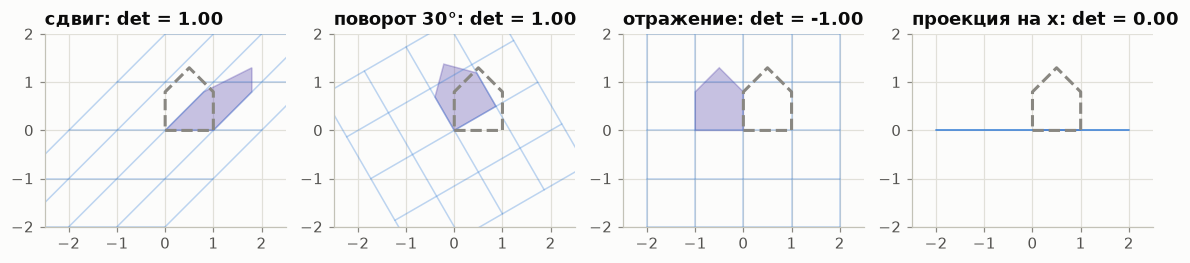

In [8]:
A = np.array([[1, 2], [3, 4.0]])
print("A·(1, 1) =", A @ [1, 1.0], " по столбцам:", A[:, 0] + A[:, 1])
print("Xw при w = (−0.4, 1.83):", (X @ [-0.4, 1.83]).round(2))
print("Xᵀr при w = (0, 1):", X.T @ (y - x))
R90 = np.array([[0, -1], [1, 0.0]])
S = np.array([[-1, 0], [0, 1.0]])
print("R90·(3, 1) =", R90 @ [3, 1.0])
B = np.array([[0, 1], [1, 0.0]])
print("AB =\n", A @ B, "\nBA =\n", B @ A)
print("SR =\n", S @ R90, "\nRS =\n", R90 @ S)
Rot = lambda f: np.array([[np.cos(f), -np.sin(f)], [np.sin(f), np.cos(f)]])
print("R(β)R(α) = R(α + β):", np.allclose(Rot(0.4) @ Rot(0.7), Rot(1.1)))

house = np.array([[0, 0], [1, 0], [1, 0.8], [0.5, 1.3], [0, 0.8], [0, 0]]).T
mats = {"сдвиг": np.array([[1, 1], [0, 1.0]]), "поворот 30°": Rot(np.pi / 6), "отражение": S, "проекция на x": np.array([[1, 0], [0, 0.0]])}
fig, axs = plt.subplots(1, 4, figsize=(13, 3.4))
for axx, (name, M) in zip(axs, mats.items()):
    for k in range(-2, 3):
        for p0, p1 in (((k, -2), (k, 2)), ((-2, k), (2, k))):
            seg = M @ np.array([p0, p1]).T
            axx.plot(seg[0], seg[1], color=BLUE, alpha=0.3, lw=1)
    axx.plot(house[0], house[1], "--", color=MUTED)
    hh = M @ house
    axx.fill(hh[0], hh[1], color=VIOLET, alpha=0.3)
    axx.set(xlim=(-2.5, 2.5), ylim=(-2, 2), aspect="equal", title=f"{name}: det = {np.linalg.det(M):.2f}")
plt.show()

### Шаги 12–13. Определитель и обратная матрица

In [9]:
print("det [[3, 1], [2, 4]] =", round(np.linalg.det(np.array([[3, 1], [2, 4.0]])), 10))
print("det 3×3 =", round(np.linalg.det(np.array([[2, 1, 0], [1, 3, 1], [0, 1, 2.0]])), 10))
M1, M2 = np.array([[3, 1], [2, 4.0]]), Rot(0.3) @ np.diag([2, 0.5])
print("det(AB) = det A · det B:", np.isclose(np.linalg.det(M1 @ M2), np.linalg.det(M1) * np.linalg.det(M2)))
area_m2 = np.array([40, 55, 63, 72.0])
Xd = np.c_[area_m2, area_m2 * 10.764]
print("det(XᵀX) для м² и футов² (относительно масштаба):", np.linalg.det(Xd.T @ Xd) / np.linalg.norm(Xd.T @ Xd) ** 2)
A = np.array([[2, 1], [1, 2.0]])
print("A⁻¹ =\n", np.linalg.inv(A) * 3, "/ 3;  A⁻¹·(3, 3) =", np.linalg.inv(A) @ [3, 3.0])
print("R⁻¹ = Rᵀ:", np.allclose(np.linalg.inv(Rot(0.5)), Rot(0.5).T))
print("обратная к [[1, 1], [1, 1.001]]:\n", np.linalg.inv(np.array([[1, 1], [1, 1.001]])).round(3))

det [[3, 1], [2, 4]] = 10.0
det 3×3 = 8.0
det(AB) = det A · det B: True
det(XᵀX) для м² и футов² (относительно масштаба): -1.6648627083361185e-18
A⁻¹ =
 [[ 2. -1.]
 [-1.  2.]] / 3;  A⁻¹·(3, 3) = [1. 1.]
R⁻¹ = Rᵀ: True
обратная к [[1, 1], [1, 1.001]]:
 [[ 1001. -1000.]
 [-1000.  1000.]]


### Шаги 14–15. Системы, метод Гаусса, ранг и обусловленность

In [10]:
def gauss(M):
    """Прямой ход метода Гаусса без перестановок (для учебных систем) — с печатью шагов."""
    M = M.astype(float).copy()
    n = M.shape[0]
    for c in range(n):
        if abs(M[c, c]) < 1e-12:
            p = next((r for r in range(c + 1, n) if abs(M[r, c]) > 1e-12), None)
            if p is None:
                continue
            M[[c, p]] = M[[p, c]]
            print(f"  меняем строки {c + 1} и {p + 1}")
        for r in range(c + 1, n):
            f = M[r, c] / M[c, c]
            if f:
                M[r] -= f * M[c]
                print(f"  R{r + 1} −= {f:g}·R{c + 1} → {M[r]}")
    return M


for name, M in (("одно решение", [[1, 1, 1, 6], [2, 1, -1, 1], [1, -1, 2, 5]]), ("нет решений", [[1, 1, 1, 6], [2, 2, 2, 10], [1, -1, 0, 0]]), ("бесконечно много", [[1, 1, 1, 6], [2, 1, -1, 1], [3, 2, 0, 7]])):
    print(name)
    T = gauss(np.array(M))
    A_, c_ = np.array(M, float)[:, :3], np.array(M, float)[:, 3]
    print("  ранг A =", np.linalg.matrix_rank(A_), " ранг [A | c] =", np.linalg.matrix_rank(np.array(M, float)))
print("решение первой системы:", np.linalg.solve(np.array([[1, 1, 1], [2, 1, -1], [1, -1, 2.0]]), [6, 1, 5.0]))

B = np.array([[1, 1], [1, 1.001]])
print(f"κ = {np.linalg.cond(B):.1f}; решения: {np.linalg.solve(B, [2, 2.001])}, {np.linalg.solve(B, [2, 2.002])}")
print("ранги:", np.linalg.matrix_rank(np.array([[1, 2], [2, 4.0]])), np.linalg.matrix_rank(np.array([[1, 0, 1], [0, 1, 1.0]])))

одно решение
  R2 −= 2·R1 → [  0.  -1.  -3. -11.]
  R3 −= 1·R1 → [ 0. -2.  1. -1.]
  R3 −= 2·R2 → [ 0.  0.  7. 21.]
  ранг A = 3  ранг [A | c] = 3
нет решений
  R2 −= 2·R1 → [ 0.  0.  0. -2.]
  R3 −= 1·R1 → [ 0. -2. -1. -6.]
  меняем строки 2 и 3
  ранг A = 2  ранг [A | c] = 3
бесконечно много
  R2 −= 2·R1 → [  0.  -1.  -3. -11.]
  R3 −= 3·R1 → [  0.  -1.  -3. -11.]
  R3 −= 1·R2 → [0. 0. 0. 0.]
  ранг A = 2  ранг [A | c] = 2
решение первой системы: [1. 2. 3.]
κ = 4002.0; решения: [1. 1.], [0. 2.]
ранги: 1 2


## Блок 3. Ортогональность и метод наименьших квадратов

### Шаг 16. Грам — Шмидт, QR и центрирование

In [11]:
a1, a2 = np.array([3.0, 1.0]), np.array([2.0, 2.0])
q1 = a1 / np.linalg.norm(a1)
e2 = a2 - (a2 @ q1) * q1
q2 = e2 / np.linalg.norm(e2)
R_ = np.array([[np.linalg.norm(a1), a2 @ q1], [0, np.linalg.norm(e2)]])
print("q1 =", q1, " q2 =", q2, " q1·q2 =", round(q1 @ q2, 15), "\nR =\n", R_)
print("QR = X:", np.allclose(np.c_[q1, q2] @ R_, np.c_[a1, a2]))
Qn, Rn = np.linalg.qr(np.c_[a1, a2])
print("numpy: |R| совпадает:", np.allclose(np.abs(Rn), np.abs(R_)))
xc = x - proj(np.ones(6), x)
print("x − проекция на 1 = центрированный x:", xc, " ⟂ 1:", xc.sum())

q1 = [0.9487 0.3162]  q2 = [-0.3162  0.9487]  q1·q2 = 0.0 
R =
 [[3.1623 2.5298]
 [0.     1.2649]]
QR = X: True
numpy: |R| совпадает: True
x − проекция на 1 = центрированный x: [-2.5 -1.5 -0.5  0.5  1.5  2.5]  ⟂ 1: 0.0


### Шаги 17–18. Проекция на подпространство и МНК

In [12]:
P3 = X3 @ np.linalg.inv(X3.T @ X3) @ X3.T
print("P (×6) =\n", (6 * P3).round(10), "\nP² = P:", np.allclose(P3 @ P3, P3), " след:", np.trace(P3).round(10), " собственные числа:", np.linalg.eigvalsh(P3).round(10))
w = np.linalg.solve(X.T @ X, X.T @ y)
res = y - X @ w
print("XᵀX =\n", X.T @ X, "\nXᵀy =", X.T @ y)
print(f"b = {w[0]:.4f}, k = {w[1]:.4f}, ‖r‖² = {res @ res:.4f}, R² = {1 - res @ res / 64:.4f}, Xᵀr = {(X.T @ res).round(12)}")
print("остатки:", res.round(3))
print("наклон через ковариацию:", ((x - x.mean()) @ (y - y.mean())) / ((x - x.mean()) @ (x - x.mean())))
print("Пифагор: 64 =", round((X @ w - 6) @ (X @ w - 6), 3), "+", round(res @ res, 3))
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X1, y)
print(f"scikit-learn: b = {lr.intercept_:.4f}, k = {lr.coef_[0]:.4f};  lstsq: {np.linalg.lstsq(X, y, rcond=None)[0].round(4)}")
assert np.isclose(res @ res, 5.4857, atol=1e-4) and np.allclose(w, [-0.4, 192 / 105])

P (×6) =
 [[ 5.  2. -1.]
 [ 2.  2.  2.]
 [-1.  2.  5.]] 
P² = P: True  след: 2.0  собственные числа: [0. 1. 1.]
XᵀX =
 [[ 6. 21.]
 [21. 91.]] 
Xᵀy = [ 36. 158.]
b = -0.4000, k = 1.8286, ‖r‖² = 5.4857, R² = 0.9143, Xᵀr = [-0. -0.]
остатки: [ 0.571  0.743 -2.086  0.086  0.257  0.429]
наклон через ковариацию: 1.8285714285714285
Пифагор: 64 = 58.514 + 5.486
scikit-learn: b = -0.4000, k = 1.8286;  lstsq: [-0.4     1.8286]


### Шаги 19–20. Полиномиальные признаки, переобучение и гребневая регрессия

 d  Σ квадратов   LOO MSE     κ сырой      κ станд.
 0     64.0000    15.3600   1.000e+00   1.000e+00
 1      5.4857     1.6650   8.760e+01   1.000e+00
 2      3.7714     2.0107   1.055e+04   8.076e+00
 3      3.5714    14.0940   2.152e+06   4.313e+01
 4      2.2857   201.6000   7.411e+08   3.489e+02
 5      0.0000        nan   5.347e+11   4.594e+03
парабола: [1.6    0.3286 0.2143]
λ = 0.0001: Σ квадратов 0.000, LOO 113.316, κ 4576
λ = 1: Σ квадратов 6.347, LOO 7.469, κ 114
лучшая LOO 4.211 при λ ≈ 3.98
ridge sklearn = наш: True


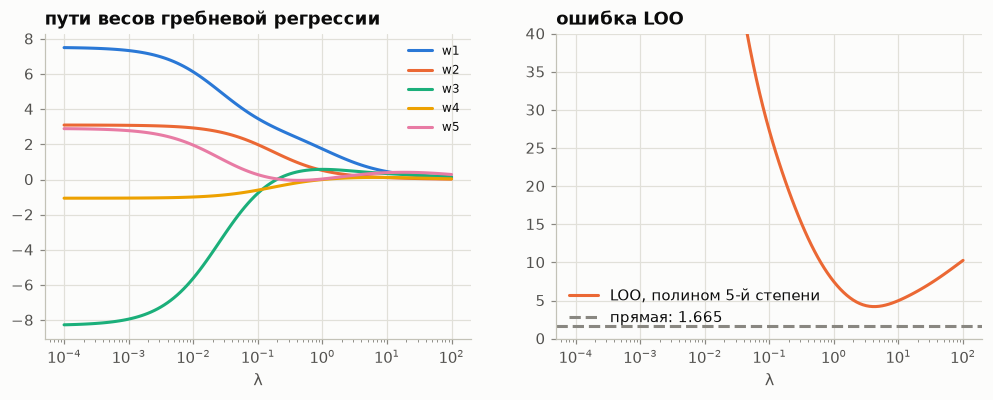

In [13]:
z = (x - x.mean()) / x.std()
print(" d  Σ квадратов   LOO MSE     κ сырой      κ станд.")
for d in range(6):
    V = np.vander(x, d + 1, increasing=True)
    wd = np.linalg.lstsq(V, y, rcond=None)[0]
    sse = ((y - V @ wd) ** 2).sum()
    if d < 5:
        loo = np.mean([(y[i] - V[i] @ np.linalg.lstsq(np.delete(V, i, 0), np.delete(y, i), rcond=None)[0]) ** 2 for i in range(6)])
    else:
        loo = float("nan")
    Vs = np.vander(z, d + 1, increasing=True)
    print(f" {d}  {sse:10.4f}  {loo:9.4f}  {np.linalg.cond(V.T @ V):10.3e}  {np.linalg.cond(Vs.T @ Vs):10.3e}")
print("парабола:", np.linalg.lstsq(np.vander(x, 3, increasing=True), y, rcond=None)[0].round(4))

V5 = np.vander(z, 6, increasing=True)
Dpen = np.diag([0, 1, 1, 1, 1, 1.0])
ridge = lambda Vm, ym, lam: np.linalg.solve(Vm.T @ Vm + lam * Dpen, Vm.T @ ym)
lams = np.logspace(-4, 2, 121)
loos = [np.mean([(y[i] - V5[i] @ ridge(np.delete(V5, i, 0), np.delete(y, i), l)) ** 2 for i in range(6)]) for l in lams]
for lam in (1e-4, 1.0):
    wr = ridge(V5, y, lam)
    print(f"λ = {lam:g}: Σ квадратов {((y - V5 @ wr) ** 2).sum():.3f}, LOO {loos[int(np.argmin(np.abs(lams - lam)))]:.3f}, κ {np.linalg.cond(V5.T @ V5 + lam * Dpen):.0f}")
ib = int(np.argmin(loos))
print(f"лучшая LOO {loos[ib]:.3f} при λ ≈ {lams[ib]:.2f}")
from sklearn.linear_model import Ridge

sk = Ridge(alpha=1.0).fit(V5[:, 1:], y)                # sklearn не штрафует свободный член
print("ridge sklearn = наш:", np.allclose(np.r_[sk.intercept_, sk.coef_], ridge(V5, y, 1.0)))

paths = np.array([ridge(V5, y, l) for l in lams])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for k in range(1, 6):
    ax[0].semilogx(lams, paths[:, k], label=f"w{k}")
ax[0].set(xlabel="λ", title="пути весов гребневой регрессии")
ax[0].legend(fontsize=8)
ax[1].semilogx(lams, loos, color=ORANGE, label="LOO, полином 5-й степени")
ax[1].axhline(1.665, color=MUTED, ls="--", label="прямая: 1.665")
ax[1].set(xlabel="λ", ylim=(0, 40), title="ошибка LOO")
ax[1].legend()
plt.show()

## Блок 4. Собственные векторы и квадратичные формы

### Шаги 21–23. Собственные числа, характеристический многочлен, степени матрицы

In [14]:
for M in ([[2, 1], [1, 2]], [[4, 1], [2, 3]], [[0, -1], [1, 0]], [[1, 1], [0, 1]], [[3, 0], [4, 5]]):
    M = np.array(M, float)
    vals, vecs = np.linalg.eig(M)
    print(f"{M.tolist()}: tr = {np.trace(M):g}, det = {np.linalg.det(M):.4g}, λ = {np.round(vals, 4)}")
Fib = np.array([[1, 1], [1, 0]])
phi = (1 + 5**0.5) / 2
print("F₂₀ =", np.linalg.matrix_power(Fib, 20)[0, 1], " φ²⁰/√5 =", phi**20 / 5**0.5)
Pm = np.array([[0.9, 0.5], [0.1, 0.5]])
s_ = np.array([0, 1.0])
for k in range(1, 11):
    s_ = Pm @ s_
    if k in (1, 2, 10):
        print(f"погода через {k}: {s_}")
vals, vecs = np.linalg.eig(Pm)
print("собственные числа:", vals, " стационарное:", vecs[:, 0] / vecs[:, 0].sum())
Hq = np.diag([1, 10.0])
print("собственные числа I − 0.15·H:", np.linalg.eigvals(np.eye(2) - 0.15 * Hq))

[[2.0, 1.0], [1.0, 2.0]]: tr = 4, det = 3, λ = [3.+0.j 1.+0.j]
[[4.0, 1.0], [2.0, 3.0]]: tr = 7, det = 10, λ = [5.+0.j 2.+0.j]
[[0.0, -1.0], [1.0, 0.0]]: tr = 0, det = 1, λ = [0.+1.j 0.-1.j]
[[1.0, 1.0], [0.0, 1.0]]: tr = 2, det = 1, λ = [1.+0.j 1.+0.j]
[[3.0, 0.0], [4.0, 5.0]]: tr = 8, det = 15, λ = [5.+0.j 3.+0.j]
F₂₀ = 6765  φ²⁰/√5 = 6765.000029563936
погода через 1: [0.5 0.5]
погода через 2: [0.7 0.3]
погода через 10: [0.8332 0.1668]
собственные числа: [1. +0.j 0.4+0.j]  стационарное: [0.8333+0.j 0.1667+0.j]
собственные числа I − 0.15·H: [ 0.85+0.j -0.5 +0.j]


### Шаги 24–25. Квадратичные формы, обусловленность и стандартизация

[[1, 0], [0, 3]]: λ = [1. 3.], чаша
[[2, 1], [1, 2]]: λ = [1. 3.], чаша
[[1, 2], [2, 1]]: λ = [-1.  3.], седло
[[1, 1], [1, 1]]: λ = [0. 2.], жёлоб
сырой x         : собственные числа H [  2.19 191.81], κ = 87.598, шагов: η = 1/λmax — 1130, лучший η — 606
центрированный  : собственные числа H [12. 35.], κ = 2.917, шагов: η = 1/λmax — 33, лучший η — 20
стандартизованный: собственные числа H [12. 12.], κ = 1.000, шагов: η = 1/λmax — 1, лучший η — 1


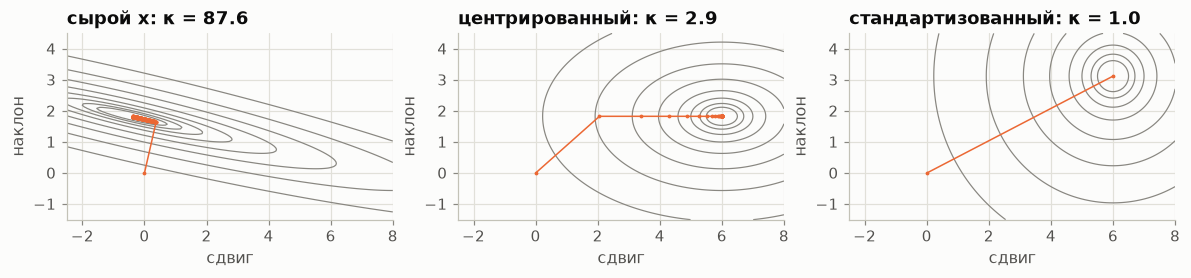

In [15]:
for M in ([[1, 0], [0, 3]], [[2, 1], [1, 2]], [[1, 2], [2, 1]], [[1, 1], [1, 1]]):
    lam = np.linalg.eigvalsh(np.array(M, float))
    kind = "чаша" if lam.min() > 1e-12 else "седло" if lam.min() < -1e-12 < 1e-12 < lam.max() else "жёлоб"
    print(f"{M}: λ = {lam}, {kind}")


def gd_steps(Xm, frac, tol=1e-6):
    H = 2 * Xm.T @ Xm
    lam = np.linalg.eigvalsh(H)
    eta = frac * 2 / lam.max()
    ws = np.linalg.solve(Xm.T @ Xm, Xm.T @ y)
    wv = np.zeros(2)
    path = [wv]
    for k in range(1, 20001):
        wv = wv - eta * (-2 * Xm.T @ (y - Xm @ wv))
        path.append(wv)
        if np.linalg.norm(wv - ws) < tol * max(1, np.linalg.norm(ws)):
            return k, lam, np.array(path)
    return None, lam, np.array(path)


fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
for axx, (name, f) in zip(axs, (("сырой x", x), ("центрированный", x - 3.5), ("стандартизованный", (x - 3.5) / x.std()))):
    Xm = np.c_[np.ones(6), f]
    k_half, lam, path = gd_steps(Xm, 0.5)
    best = lam.max() / (lam.min() + lam.max())
    k_best, _, _ = gd_steps(Xm, best)
    print(f"{name:16}: собственные числа H {lam.round(3)}, κ = {lam.max() / lam.min():.3f}, шагов: η = 1/λmax — {k_half}, лучший η — {k_best}")
    B_, K_ = np.meshgrid(np.linspace(-2.5, 8, 120), np.linspace(-1.5, 4.5, 120))
    Z = sum((y[i] - B_ - K_ * f[i]) ** 2 for i in range(6))
    axx.contour(B_, K_, Z, levels=np.sort(Z.min() + np.array([1.5, 3, 6, 12, 25, 50, 100, 200])), colors=MUTED, linewidths=0.8)
    axx.plot(path[:300, 0], path[:300, 1], ".-", color=ORANGE, ms=3, lw=1)
    axx.set(aspect="equal", title=f"{name}: κ = {lam.max() / lam.min():.1f}", xlabel="сдвиг", ylabel="наклон")
plt.show()

## Блок 5. Сингулярное разложение и главные компоненты

### Шаги 26–27. SVD и малоранговое приближение

σ = [6.7082 2.2361]  σ² = собственные числа MᵀM: [45.  5.]  σ₁σ₂ = 15.0  κ = 3.0
сингулярные числа [[1, 1], [1, 1]]: [2. 0.]  pinv·(2, 2) = [1. 1.]
ранг картинки: 23  первые σ: [15.905  5.475  3.791]
ранг  1:   81 чисел (5%), ошибка 46.4%
ранг  5:  405 чисел (25%), ошибка 21.0%
ранг 10:  810 чисел (51%), ошибка 12.1%
ранг 15: 1215 чисел (76%), ошибка 6.2%


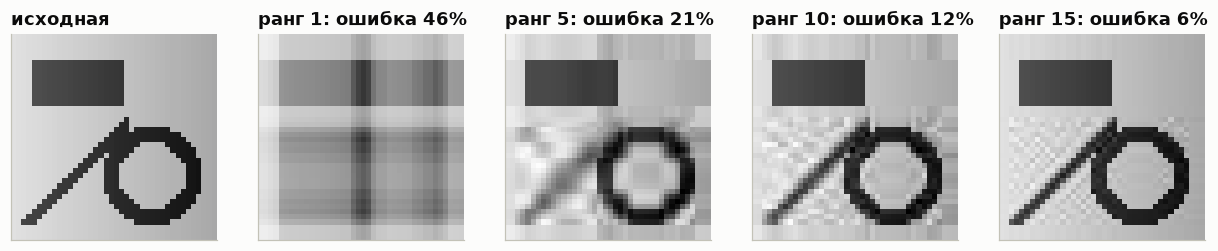

In [16]:
M = np.array([[3, 0], [4, 5.0]])
U_, s, Vt = np.linalg.svd(M)
print("σ =", s.round(4), " σ² = собственные числа MᵀM:", np.linalg.eigvalsh(M.T @ M)[::-1], " σ₁σ₂ =", s.prod().round(6), " κ =", (s[0] / s[1]).round(6))
print("сингулярные числа [[1, 1], [1, 1]]:", np.linalg.svd(np.ones((2, 2)), compute_uv=False), " pinv·(2, 2) =", np.linalg.pinv(np.ones((2, 2))) @ [2, 2.0])

N = 40
img = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        val = 0.12 + 0.22 * j / (N - 1)
        if 5 <= i <= 13 and 4 <= j <= 21:
            val += 0.55
        if abs(np.hypot(i - 27, j - 27) - 8) <= 1.6:
            val += 0.6
        if 3 <= i <= 36 and abs(i - (N - 1 - j)) <= 1.2 and j <= 22:
            val += 0.6
        img[i, j] = min(val, 1.0)
U_, s, Vt = np.linalg.svd(img)
print("ранг картинки:", np.linalg.matrix_rank(img), " первые σ:", s[:3].round(3))
fig, axs = plt.subplots(1, 5, figsize=(14, 3))
axs[0].imshow(img, cmap="gray_r", vmin=0, vmax=1)
axs[0].set_title("исходная")
for axx, k in zip(axs[1:], (1, 5, 10, 15)):
    approx = (U_[:, :k] * s[:k]) @ Vt[:k]
    err = np.linalg.norm(img - approx) / np.linalg.norm(img)
    print(f"ранг {k:2d}: {k * (2 * N + 1):4d} чисел ({k * (2 * N + 1) / N / N:.0%}), ошибка {err:.1%}")
    axx.imshow(approx, cmap="gray_r", vmin=0, vmax=1)
    axx.set_title(f"ранг {k}: ошибка {err:.0%}")
for axx in axs:
    axx.set(xticks=[], yticks=[])
plt.show()

### Шаг 28. Ковариация и PCA

In [17]:
Pc = np.c_[x - x.mean(), y - y.mean()]
C = Pc.T @ Pc / 5
lam, V = np.linalg.eigh(C)
print("C =\n", C, "\nкорреляция:", C[0, 1] / np.sqrt(C[0, 0] * C[1, 1]), " = косинус центрированных столбцов:", cs(Pc[:, 0], Pc[:, 1]))
print(f"λ = {lam.round(3)}, доля PC1 {lam[1] / lam.sum():.4f}, наклон PC1 {V[1, 1] / V[0, 1]:.4f}, МНК {32 / 17.5:.4f}")
from sklearn.decomposition import PCA

pca = PCA().fit(np.c_[x, y])
print("sklearn PCA:", pca.explained_variance_.round(4), pca.components_[0].round(4))

C =
 [[ 3.5  6.4]
 [ 6.4 12.8]] 
корреляция: 0.9561828874675149  = косинус центрированных столбцов: 0.9561828874675149
λ = [ 0.239 16.061], доля PC1 0.9853, наклон PC1 1.9626, МНК 1.8286
sklearn PCA: [16.0609  0.2391] [0.454 0.891]


## Блок 6. Линейная алгебра бустинга

### Шаги 29–30. Дерево — проекция; выигрыш — квадрат длины проекции

In [18]:
r = y - y.mean()
print("порог  листья          ‖h‖²   ‖r−h‖²   Σ G²/n")
for t in (1.5, 2.5, 3.5, 4.5, 5.5):
    L = np.c_[x <= t, x > t].astype(float)
    theta = np.linalg.solve(L.T @ L, L.T @ r)
    hh = L @ theta
    gain = sum((L[:, j] @ r) ** 2 / L[:, j].sum() for j in range(2))
    print(f"{t}    {theta.round(3)}   {hh @ hh:6.2f}   {(r - hh) @ (r - hh):6.2f}   {gain:6.2f}   ⟂: {(L.T @ (r - hh)).round(12)}")
L3 = np.c_[x <= 3.5, (x > 3.5) & (x <= 4.5), x > 4.5].astype(float)
h3 = L3 @ np.linalg.solve(L3.T @ L3, L3.T @ r)
print("три листа (3.5, 4.5):", h3, " ‖h‖² =", h3 @ h3)
for lam_ in (0, 1):
    print(f"λ = {lam_}: выигрыш порога 3.5 = {81 / (3 + lam_) * 2:.1f}, порога 1.5 = {16 / (1 + lam_) + 16 / (5 + lam_):.2f}")
stump = GBRegressor(n_estimators=1, learning_rate=1.0, max_depth=1).fit(X1, y)
print("пень gbcourse:", stump.predict(X1), "= 6 + проекция при пороге 3.5")
from sklearn.tree import DecisionTreeRegressor

sk_tree = DecisionTreeRegressor(max_depth=1).fit(X1, r)
print("sklearn: порог", sk_tree.tree_.threshold[0], " листья", sk_tree.tree_.value.ravel()[1:])

порог  листья          ‖h‖²   ‖r−h‖²   Σ G²/n
1.5    [-4.   0.8]    19.20    44.80    19.20   ⟂: [0. 0.]
2.5    [-3.   1.5]    27.00    37.00    27.00   ⟂: [0. 0.]
3.5    [-3.  3.]    54.00    10.00    54.00   ⟂: [0. 0.]
4.5    [-2.  4.]    48.00    16.00    48.00   ⟂: [0. 0.]
5.5    [-1.  5.]    30.00    34.00    30.00   ⟂: [0. 0.]
три листа (3.5, 4.5): [-3. -3. -3.  1.  4.  4.]  ‖h‖² = 60.0
λ = 0: выигрыш порога 3.5 = 54.0, порога 1.5 = 19.20
λ = 1: выигрыш порога 3.5 = 40.5, порога 1.5 = 10.67
пень gbcourse: [3. 3. 3. 9. 9. 9.] = 6 + проекция при пороге 3.5
sklearn: порог 3.5  листья [-3.  3.]


### Шаг 31. Бустинг — цепочка проекций

ν = 1.0: ‖r‖² [64.   10.    5.2   4.24] … m=10: 0.3430 (gbcourse 0.3430); пороги [3.5, 5.5, 3.5, 1.5, 2.5, 4.5]
ν = 0.5: ‖r‖² [64.     23.5     9.4375  4.8812] … m=10: 0.4684 (gbcourse 0.4684); пороги [3.5, 4.5, 5.5, 1.5, 3.5, 5.5]
ν = 0.1: ‖r‖² [64.     53.74   45.4294 38.6978] … m=10: 13.8213 (gbcourse 13.8213); пороги [3.5, 3.5, 3.5, 4.5, 4.5, 3.5]


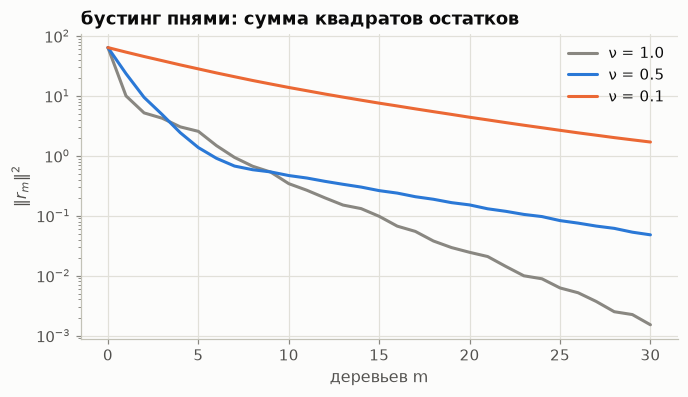

падение на первом шаге = (2ν − ν²)·54: [10, 23.5, 53.74]


In [19]:
def boost(nu, M):
    F = np.full(6, y.mean())
    hist, cuts = [((y - F) ** 2).sum()], []
    for _ in range(M):
        rr = y - F
        best = max(((t, np.where(x <= t, rr[x <= t].mean(), rr[x > t].mean())) for t in (1.5, 2.5, 3.5, 4.5, 5.5)), key=lambda p: (p[1] @ p[1], -p[0]))
        F = F + nu * best[1]
        cuts.append(best[0])
        hist.append(((y - F) ** 2).sum())
    return np.array(hist), cuts, F


fig, ax = plt.subplots(figsize=(7, 3.6))
for nu, col in ((1.0, MUTED), (0.5, BLUE), (0.1, ORANGE)):
    hist, cuts, F = boost(nu, 30)
    gb = GBRegressor(n_estimators=10, learning_rate=nu, max_depth=1).fit(X1, y)
    print(f"ν = {nu}: ‖r‖² {hist[:4].round(4)} … m=10: {hist[10]:.4f} (gbcourse {((y - gb.predict(X1)) ** 2).sum():.4f}); пороги {cuts[:6]}")
    ax.semilogy(hist, color=col, label=f"ν = {nu}")
ax.set(xlabel="деревьев m", ylabel=r"$\Vert r_m \Vert^2$", title="бустинг пнями: сумма квадратов остатков")
ax.legend()
plt.show()
print("падение на первом шаге = (2ν − ν²)·54:", [64 - (2 * n - n * n) * 54 for n in (1, 0.5, 0.1)])

### Шаг 32. Лист Ньютона — взвешенная проекция с λ

Сверим формулу $w = -G/(H + \lambda)$ = взвешенное среднее рабочих ответов с листом XGBoost.

In [20]:
from scipy.optimize import brentq

for name, F0, yy in (("первый шаг", np.zeros(4), np.array([1, 1, 1, 0.0])), ("смешанный", np.array([2, 0.5, -0.5, 1.0]), np.array([1, 1, 0, 0.0])), ("чистый", np.array([3, 4, 2.5, 3.5]), np.ones(4))):
    pr = 1 / (1 + np.exp(-F0))
    g, hs = pr - yy, pr * (1 - pr)
    zz = -g / hs
    dl = lambda w: np.sum(1 / (1 + np.exp(-(F0 + w))) - yy)
    opt = brentq(dl, -30, 30) if dl(-30) < 0 < dl(30) else None
    print(f"{name}: z = {zz.round(3)}, h = {hs.round(3)}, w(λ=0) = {-g.sum() / hs.sum():.4f}, w(λ=1) = {-g.sum() / (hs.sum() + 1):.4f}, "
          f"взвешенное среднее z = {(hs * zz).sum() / hs.sum():.4f}, точный оптимум = {opt if opt is None else round(opt, 4)}")
import xgboost as xgb

Xs = np.zeros((4, 1))                                   # одинаковые признаки: дерево — один лист
F0, yy = np.array([2, 0.5, -0.5, 1.0]), np.array([1, 1, 0, 0.0])
for lam_ in (0, 1):
    dm = xgb.DMatrix(Xs, label=yy, base_margin=F0)
    bst = xgb.train({"objective": "binary:logistic", "eta": 1, "lambda": lam_, "max_depth": 1, "min_child_weight": 0}, dm, 1)
    leaf = bst.predict(dm, output_margin=True) - F0
    pr = 1 / (1 + np.exp(-F0))
    print(f"XGBoost, λ = {lam_}: лист {leaf[0]:.4f}, формула {-(pr - yy).sum() / ((pr * (1 - pr)).sum() + lam_):.4f}")

первый шаг: z = [ 2.  2.  2. -2.], h = [0.25 0.25 0.25 0.25], w(λ=0) = 1.0000, w(λ=1) = 0.5000, взвешенное среднее z = 1.0000, точный оптимум = 1.0986
смешанный: z = [ 1.135  1.607 -1.607 -3.718], h = [0.105 0.235 0.235 0.197], w(λ=0) = -0.7930, w(λ=1) = -0.3454, взвешенное среднее z = -0.7930, точный оптимум = -0.75
чистый: z = [1.05  1.018 1.082 1.03 ], h = [0.045 0.018 0.07  0.028], w(λ=0) = 1.0569, w(λ=1) = 0.1469, взвешенное среднее z = 1.0569, точный оптимум = None
XGBoost, λ = 0: лист -0.7930, формула -0.7930
XGBoost, λ = 1: лист -0.3454, формула -0.3454


### Шаг 33. Ансамбль — линейная модель на индикаторах листьев

In [21]:
hist, cuts, F = boost(0.5, 3)
Phi = np.concatenate([np.c_[x <= t, x > t] for t in cuts], axis=1).astype(float)
theta_ls = np.linalg.lstsq(Phi, y - 6, rcond=None)[0]
print("пороги", cuts, " ранг Φ:", np.linalg.matrix_rank(Phi), "из", Phi.shape[1])
print(f"Σ квадратов: бустинг {hist[-1]:.4f}, совместная подгонка {((y - 6 - Phi @ theta_ls) ** 2).sum():.4f}")

# Проверка на XGBoost: индексы листьев → one-hot → линейная модель точно воспроизводит прогнозы
Xr, yr = datasets.friedman1(n=300, seed=3)
bst = xgb.train({"max_depth": 3, "eta": 0.3, "lambda": 1, "base_score": 0.0}, xgb.DMatrix(Xr, label=yr), 20)
leaves = bst.predict(xgb.DMatrix(Xr), pred_leaf=True).astype(int)
from sklearn.preprocessing import OneHotEncoder

Phi_x = OneHotEncoder().fit_transform(leaves).toarray()
pred = bst.predict(xgb.DMatrix(Xr))
theta = np.linalg.lstsq(Phi_x, pred, rcond=None)[0]
print(f"XGBoost: {Phi_x.shape[1]} индикаторов листьев, ранг {np.linalg.matrix_rank(Phi_x)}; линейная модель на них воспроизводит прогнозы: max|разница| = {np.abs(Phi_x @ theta - pred).max():.2e}")
lr2 = LinearRegression().fit(Phi_x, yr)
print(f"совместная подгонка листьев: Σ квадратов на обучении {((yr - pred) ** 2).sum():.2f} → {((yr - lr2.predict(Phi_x)) ** 2).sum():.2f}")

пороги [3.5, 4.5, 5.5]  ранг Φ: 4 из 6
Σ квадратов: бустинг 4.8812, совместная подгонка 2.0000
XGBoost: 153 индикаторов листьев, ранг 130; линейная модель на них воспроизводит прогнозы: max|разница| = 2.30e-06
совместная подгонка листьев: Σ квадратов на обучении 292.27 → 124.41


## Упражнения

Условия — `exercises/tasks.md`, решения — `exercises/solutions.py`.

1. ★☆☆ Действия с векторами, скалярное произведение и угол.
2. ★☆☆ Нормы остатков и потери; медиана и среднее.
3. ★☆☆ Проекция вектора и проверка перпендикулярности.
4. ★★☆ Определитель, обратная матрица и система $2 \times 2$.
5. ★★☆ Метод Гаусса для системы $3 \times 3$.
6. ★★☆ МНК-прямая по трём точкам через нормальные уравнения.
7. ★★☆ Собственные числа и векторы, устойчивый темп спуска.
8. ★★☆ Квадратичная форма: тип и оси.
9. ★★★ Парабола и полином 5-й степени: переобучение и гребневая регрессия.
10. ★★★ SVD матрицы $2 \times 2$ и малоранговое приближение.
11. ★★★ Дерево как проекция: листья, выигрыш, λ.
12. ★★★ Лист Ньютона для логистических потерь и сверка с XGBoost.